In [ ]:
!pip install -q tensorflow==2.18.1 tf-keras==2.18.0 tensorflow-quantum cirq==1.5.0

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import random
import numpy as np
import tensorflow as tf
import tensorflow_quantum as tfq
import cirq
import sympy
import random

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import(
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
from cirq.contrib.svg import SVGCircuit
from tensorflow.keras import regularizers

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DATA_DIR = "/content/drive/MyDrive/PCOS"

IMG_SIZE = 128
BATCH_SIZE = 16
SEED = 42

N_QUBITS = 8
EPOCHS = 50
LEARNING_RATE = 0.01

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    label_mode="binary",
    shuffle=True
)

class_names = dataset.class_names
print("Clases detectadas:", class_names)

Found 2000 files belonging to 2 classes.
Clases detectadas: ['infected', 'noninfected']


In [ ]:
normalization_layer = tf.keras.layers.Rescaling(1.0 / 255.0)

dataset = dataset.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

dataset = dataset.prefetch(tf.data.AUTOTUNE)

In [ ]:
def dataset_to_numpy(ds):
    images_list = []
    labels_list = []

    for images, labels in ds:
        images_list.append(images.numpy())
        labels_list.append(labels.numpy())

    X = np.concatenate(images_list, axis=0)
    y = np.concatenate(labels_list, axis=0).reshape(-1)

    return X, y


X_all, y_all = dataset_to_numpy(dataset)

print("X_all:", X_all.shape)
print("y_all:", y_all.shape)

X_all: (2000, 128, 128, 1)
y_all: (2000,)


In [ ]:
unique, counts = np.unique(y_all, return_counts=True)

print("\nDistribución de clases:")
for clase, count in zip(unique, counts):
    print(f"Clase {int(clase)}: {count} imágenes")


Distribución de clases:
Clase 0: 1000 imágenes
Clase 1: 1000 imágenes


In [ ]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X_all,
    y_all,
    test_size=0.15,
    random_state=SEED,
    stratify=y_all
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.1765,
    random_state=SEED,
    stratify=y_temp
)

print("\nDivisión final:")
print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)


División final:
Train: (1399, 128, 128, 1) (1399,)
Val  : (301, 128, 128, 1) (301,)
Test : (300, 128, 128, 1) (300,)


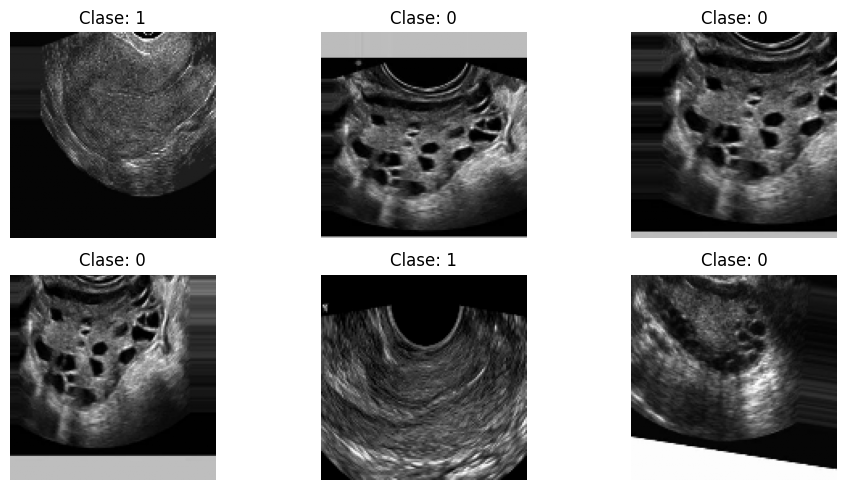

In [ ]:
plt.figure(figsize=(10, 5))

for i in range(min(6, len(X_train))):
  plt.subplot(2, 3, i + 1)
  plt.imshow(X_train[i].squeeze(), cmap="gray")
  plt.title(f"Clase: {int(y_train[i])}")
  plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def preparar_imagenes_basico(X):

  X_flat = X.reshape(X.shape[0], -1)

  return X_flat.astype(np.float32)

X_train_flat = preparar_imagenes_basico(X_train)
X_val_flat   = preparar_imagenes_basico(X_val)
X_test_flat  = preparar_imagenes_basico(X_test)

print("\nVectores planos:")
print("X_train_flat:", X_train_flat.shape)
print("X_val_flat  :", X_val_flat.shape)
print("X_test_flat :", X_test_flat.shape)


Vectores planos:
X_train_flat: (1399, 16384)
X_val_flat  : (301, 16384)
X_test_flat : (300, 16384)


In [ ]:
pca = PCA(n_components=N_QUBITS, random_state=SEED)

Q_train = pca.fit_transform(X_train_flat)
Q_val   = pca.transform(X_val_flat)
Q_test  = pca.transform(X_test_flat)

print("\nVarianza explicada por PCA:")
print(pca.explained_variance_ratio_)


Varianza explicada por PCA:
[0.21904343 0.12785205 0.05755256 0.04903187 0.0376986  0.02888985
 0.02475153 0.02046904]


In [ ]:
def scale_to_pi(x, x_min=None, x_max=None):

  if x_min is None:
    x_min = x.min(axis=0, keepdims=True)

  if x_max is None:
    x_max = x.max(axis=0, keepdims=True)

  x_scaled = 2.0 * (x - x_min) / (x_max - x_min + 1e-8) - 1.0
  x_scaled = x_scaled * np.pi

  return x_scaled, x_min, x_max


Q_train, q_min, q_max = scale_to_pi(Q_train)
Q_val, _, _ = scale_to_pi(Q_val, q_min, q_max)
Q_test, _, _ = scale_to_pi(Q_test, q_min, q_max)

Q_train = Q_train.astype(np.float32)
Q_val   = Q_val.astype(np.float32)
Q_test  = Q_test.astype(np.float32)

print("\nVectores para codificación cuántica:")
print("Q_train:", Q_train.shape)
print("Q_val  :", Q_val.shape)
print("Q_test :", Q_test.shape)


Vectores para codificación cuántica:
Q_train: (1399, 8)
Q_val  : (301, 8)
Q_test : (300, 8)


In [ ]:
qubits = cirq.GridQubit.rect(1, N_QUBITS)

In [ ]:
def circuito_codificacion(sample):

  circuit = cirq.Circuit()

  for i, q in enumerate(qubits):
    circuit.append(cirq.rx(sample[i])(q))

  return circuit

train_circuits = [circuito_codificacion(x) for x in Q_train]
val_circuits   = [circuito_codificacion(x) for x in Q_val]
test_circuits  = [circuito_codificacion(x) for x in Q_test]

X_train_tfq = tfq.convert_to_tensor(train_circuits)
X_val_tfq   = tfq.convert_to_tensor(val_circuits)
X_test_tfq  = tfq.convert_to_tensor(test_circuits)

y_train = y_train.astype(np.float32)
y_val   = y_val.astype(np.float32)
y_test  = y_test.astype(np.float32)

print("\nCircuitos de codificación convertidos a tensores TFQ:")
print("X_train_tfq:", X_train_tfq.shape)
print("X_val_tfq  :", X_val_tfq.shape)
print("X_test_tfq :", X_test_tfq.shape)


Circuitos de codificación convertidos a tensores TFQ:
X_train_tfq: (1399,)
X_val_tfq  : (301,)
X_test_tfq : (300,)


In [ ]:
params = sympy.symbols("theta0:20")

def quantum_conv_block(circuit, q1, q2, theta1, theta2):

  circuit.append(cirq.ry(theta1)(q1))
  circuit.append(cirq.ry(theta2)(q2))
  circuit.append(cirq.CNOT(q1, q2))

  return circuit

def quantum_pooling_block(circuit, q_control, q_target, theta):

  circuit.append(cirq.CNOT(q_control, q_target))
  circuit.append(cirq.ry(theta)(q_target))

  return circuit

def build_qcnn():

  circuit = cirq.Circuit()

  # --------------------------------------------------------
  # 1. Filtración / convolución local
  # --------------------------------------------------------
  quantum_conv_block(circuit, qubits[0], qubits[1], params[0], params[1])
  quantum_conv_block(circuit, qubits[2], qubits[3], params[2], params[3])
  quantum_conv_block(circuit, qubits[4], qubits[5], params[4], params[5])
  quantum_conv_block(circuit, qubits[6], qubits[7], params[6], params[7])

  # --------------------------------------------------------
  # 2. Entrelazamiento regional
  # --------------------------------------------------------
  circuit.append(cirq.CNOT(qubits[1], qubits[2]))
  circuit.append(cirq.CNOT(qubits[3], qubits[4]))
  circuit.append(cirq.CNOT(qubits[5], qubits[6]))

  # --------------------------------------------------------
  # 3. Compresión / pooling cuántico
  # --------------------------------------------------------
  quantum_pooling_block(circuit, qubits[0], qubits[1], params[8])
  quantum_pooling_block(circuit, qubits[2], qubits[3], params[9])
  quantum_pooling_block(circuit, qubits[4], qubits[5], params[10])
  quantum_pooling_block(circuit, qubits[6], qubits[7], params[11])

  # --------------------------------------------------------
  # 4. Capa final parametrizada
  # --------------------------------------------------------
  for i in range(N_QUBITS):
    circuit.append(cirq.ry(params[12 + i])(qubits[i]))

  return circuit


qcnn_circuit = build_qcnn()

print("\nCircuito QCNN parametrizado:")
print(qcnn_circuit)


Circuito QCNN parametrizado:
(0, 0): ───Ry(theta0)───@───────@───Ry(theta12)─────────────────
                        │       │
(0, 1): ───Ry(theta1)───X───@───X───Ry(theta8)────Ry(theta13)───
                            │
(0, 2): ───Ry(theta2)───@───X───@───Ry(theta14)─────────────────
                        │       │
(0, 3): ───Ry(theta3)───X───@───X───Ry(theta9)────Ry(theta15)───
                            │
(0, 4): ───Ry(theta4)───@───X───@───Ry(theta16)─────────────────
                        │       │
(0, 5): ───Ry(theta5)───X───@───X───Ry(theta10)───Ry(theta17)───
                            │
(0, 6): ───Ry(theta6)───@───X───@───Ry(theta18)─────────────────
                        │       │
(0, 7): ───Ry(theta7)───X───────X───Ry(theta11)───Ry(theta19)───


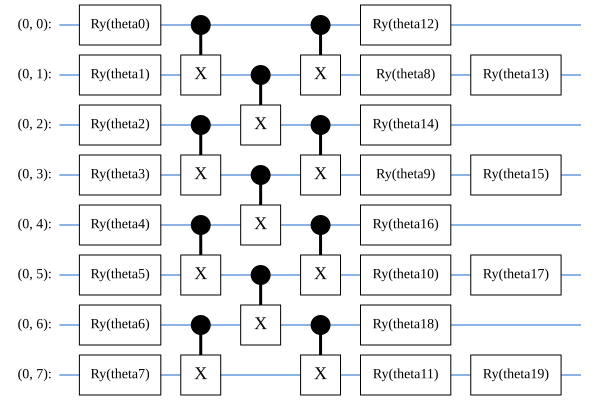

In [ ]:
SVGCircuit(qcnn_circuit)

In [ ]:
readout_operators = [
    cirq.Z(qubits[1]),
    cirq.Z(qubits[3]),
    cirq.Z(qubits[5]),
    cirq.Z(qubits[7])
]

In [ ]:
entrada_cuantica = tf.keras.Input(shape=(), dtype=tf.string, name="entrada_cuantica")

salida_cuantica = tfq.layers.PQC(model_circuit=qcnn_circuit, operators=readout_operators)(entrada_cuantica)

x = tf.keras.layers.Dense(8, activation="relu", name="capa_densa_final")(salida_cuantica)
x = tf.keras.layers.Dropout(0.2, name="dropout_final")(x)

salida = tf.keras.layers.Dense(1, activation="sigmoid", name="salida_binaria")(x)

modelo_qcnn = tf.keras.Model(inputs=entrada_cuantica, outputs=salida, name="modelo_qcnn")

modelo_qcnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE), loss="binary_crossentropy",
                    metrics=[
                        "accuracy",
                        tf.keras.metrics.Precision(name="precision"),
                        tf.keras.metrics.Recall(name="recall"),
                        tf.keras.metrics.AUC(name="auc")
                    ]
)

modelo_qcnn.summary()

Model: "modelo_qcnn"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 entrada_cuantica (InputLay  [(None,)]                 0         
 er)                                                             
                                                                 
 pqc_1 (PQC)                 (None, 4)                 20        
                                                                 
 capa_densa_final (Dense)    (None, 8)                 40        
                                                                 
 dropout_final (Dropout)     (None, 8)                 0         
                                                                 
 salida_binaria (Dense)      (None, 1)                 9         
                                                                 
Total params: 69 (276.00 Byte)
Trainable params: 69 (276.00 Byte)
Non-trainable params: 0 (0.00 Byte)
___________________

/usr/local/lib/python3.12/dist-packages/tf_keras/src/initializers/initializers.py:121: UserWarning: The initializer RandomUniform is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


In [ ]:
callbacks = [tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)]

history = modelo_qcnn.fit(
    X_train_tfq,
    y_train,
    validation_data=(X_val_tfq, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
88/88 [==============================] - 5s 28ms/step - loss: 0.6410 - accuracy: 0.6312 - precision: 0.6111 - recall: 0.7229 - auc: 0.7060 - val_loss: 0.6014 - val_accuracy: 0.7010 - val_precision: 0.6376 - val_recall: 0.9267 - val_auc: 0.7577
Epoch 2/50
88/88 [==============================] - 2s 20ms/step - loss: 0.5513 - accuracy: 0.7212 - precision: 0.7067 - recall: 0.7571 - auc: 0.7874 - val_loss: 0.5193 - val_accuracy: 0.7342 - val_precision: 0.6944 - val_recall: 0.8333 - val_auc: 0.8147
Epoch 3/50
88/88 [==============================] - 2s 20ms/step - loss: 0.4981 - accuracy: 0.7613 - precision: 0.7466 - recall: 0.7914 - auc: 0.8289 - val_loss: 0.4876 - val_accuracy: 0.7309 - val_precision: 0.7143 - val_recall: 0.7667 - val_auc: 0.8302
Epoch 4/50
88/88 [==============================] - 2s 20ms/step - loss: 0.4912 - accuracy: 0.7513 - precision: 0.7280 - recall: 0.8029 - auc: 0.8306 - val_loss: 0.4740 - val_accuracy: 0.7608 - val_precision: 0.7191 - val_recall: 0.853

In [ ]:
y_prob = modelo_qcnn.predict(X_test_tfq, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

In [ ]:
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4, zero_division=0))


Reporte de clasificación:
              precision    recall  f1-score   support

    infected     0.8993    0.8333    0.8651       150
 noninfected     0.8447    0.9067    0.8746       150

    accuracy                         0.8700       300
   macro avg     0.8720    0.8700    0.8698       300
weighted avg     0.8720    0.8700    0.8698       300




Matriz de confusión:
[[125  25]
 [ 14 136]]


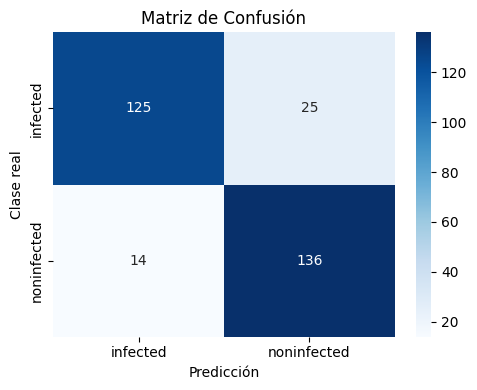

In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("\nMatriz de confusión:")
print(cm)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicción")
plt.ylabel("Clase real")
plt.title("Matriz de Confusión")
plt.tight_layout()
plt.show()

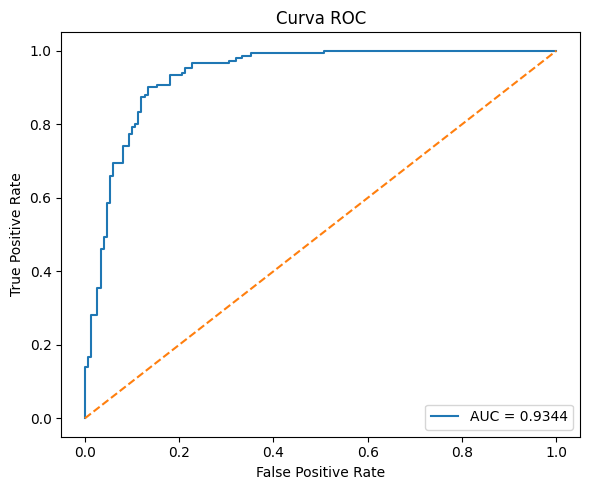

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

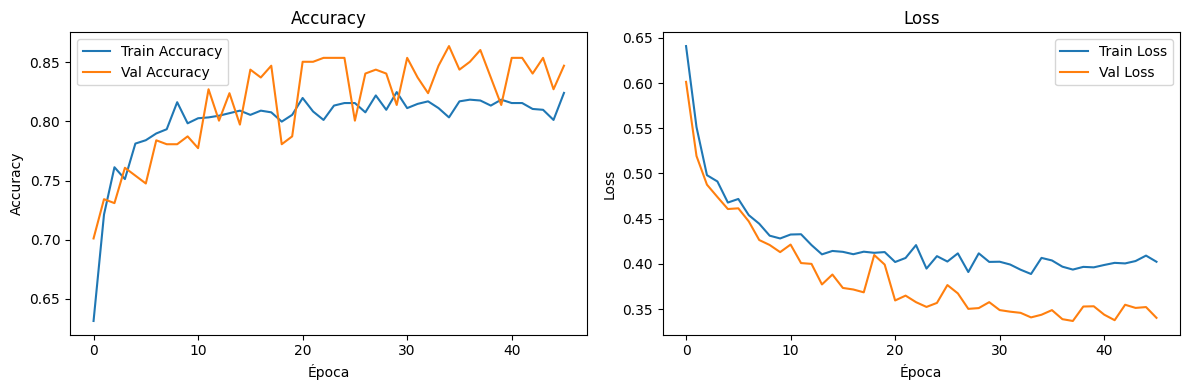

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()

plt.tight_layout()
plt.show()